In [58]:
from sklearn.model_selection import RandomizedSearchCV,train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd

In [59]:
x,y = make_regression(n_samples=1000,n_features=10,random_state=42,noise=0.2 )

In [60]:
x.shape,y.shape

((1000, 10), (1000,))

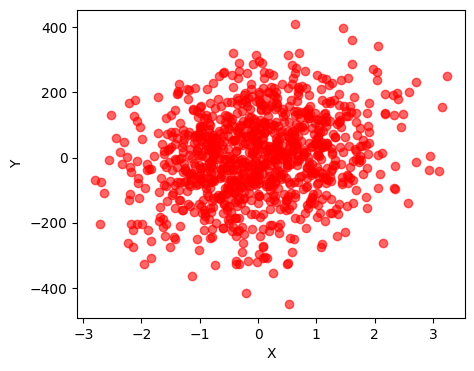

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.scatter(x[:,0],y, color = 'Red', alpha = 0.6, label = 'Data points')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


In [62]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,y_train.shape

((800, 10), (800,))

In [63]:
params = {
    'n_estimators': [50,100,150,200],
    'max_samples': [None,0.5,0.7],
    'max_features':[None,'sqrt','log2']
}

clf = RandomizedSearchCV(RandomForestRegressor(), params, cv = 5, n_jobs=-1, random_state=42, scoring='r2', n_iter=20)

In [64]:
clf.fit(x_train,y_train)

print(clf.best_score_)

0.8320587231838749


In [65]:
df = pd.DataFrame(clf.cv_results_)
df.head(1)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_max_samples,param_max_features,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.381964,0.160018,0.049212,0.006248,200,0.7,log2,"{'n_estimators': 200, 'max_samples': 0.7, 'max...",0.80764,0.813467,0.7611,0.834381,0.829465,0.80921,0.025996,12


In [66]:
df['params'][0]

{'n_estimators': 200, 'max_samples': 0.7, 'max_features': 'log2'}

In [67]:
important_df = df[['rank_test_score', 'mean_test_score', 'std_test_score', 'params', 'mean_fit_time']]
important_df = important_df.sort_values(by='rank_test_score')

print(important_df.head())

    rank_test_score  mean_test_score  std_test_score  \
19                1         0.832059        0.026814   
10                2         0.831823        0.027203   
18                3         0.828849        0.026558   
8                 4         0.828425        0.022733   
12                5         0.827875        0.024045   

                                               params  mean_fit_time  
19  {'n_estimators': 100, 'max_samples': None, 'ma...       1.037102  
10  {'n_estimators': 100, 'max_samples': 0.7, 'max...       1.264759  
18  {'n_estimators': 200, 'max_samples': 0.7, 'max...       1.781921  
8   {'n_estimators': 50, 'max_samples': 0.7, 'max_...       0.533022  
12  {'n_estimators': 50, 'max_samples': None, 'max...       0.680395  


In [70]:
important_df.loc[[19]]

,rank_test_score,mean_test_score,std_test_score,params,mean_fit_time
19,1,0.832059,0.026814,"{'n_estimators': 100, 'max_samples': None, 'ma...",1.037102


In [73]:
clf2 = RandomForestRegressor(n_estimators=100, max_samples=None, max_features=None, random_state = 42)

clf2.fit(x_train,y_train)
y_pred = clf2.predict(x_test)

print(r2_score(y_pred=y_pred, y_true=y_test))

0.8453612452551114
